In [1]:
import mne
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from mne import combine_evoked
from mne.minimum_norm import apply_inverse
import random
from mne.datasets import sample
import math
from mne.datasets import fetch_fsaverage
import os.path as op
import seaborn as sns
import pandas as pd
import statsmodels.stats.api as sms
import statsmodels

In [2]:
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)
subject = 'fsaverage'
trans = 'fsaverage'  # MNE has a built-in fsaverage transformation
snr = 3.0
lambda2 = 1.0 / snr ** 2
src = mne.setup_source_space(subject, spacing='ico4', add_dist='patch',subjects_dir=subjects_dir)
conductivity = (0.3, 0.006, 0.3)  # for three layers
model = mne.make_bem_model(subject=subject, ico=3,conductivity=conductivity,subjects_dir=subjects_dir)
bem = mne.make_bem_solution(model)

stc_EFE1 = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_beta')
stc_EFE1_p = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_mlog10_p_val')
stc_EX1 = mne.read_source_estimate('./stc_result/reg_SCE_EX1_beta')
stc_EX1_p = mne.read_source_estimate('./stc_result/reg_SCE_EX1_mlog10_p_val')
stc_AI1 = mne.read_source_estimate('./stc_result/reg_SCE_AI1_beta')
stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')
stc_AL1 = mne.read_source_estimate('./stc_result/reg_SCE_AL1_beta')
stc_AL1_p = mne.read_source_estimate('./stc_result/reg_SCE_AL1_mlog10_p_val')
stc_EFE2 = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_beta')
stc_EFE2_p = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_mlog10_p_val')
stc_AL2 = mne.read_source_estimate('./stc_result/reg_SRE_AL2_beta')
stc_AL2_p = mne.read_source_estimate('./stc_result/reg_SRE_AL2_mlog10_p_val')
stc_EX2 = mne.read_source_estimate('./stc_result/reg_SRE_EX2_beta')
stc_EX2_p = mne.read_source_estimate('./stc_result/reg_SRE_EX2_mlog10_p_val')
stc_REX2 = mne.read_source_estimate('./stc_result/reg_SRR_REX2_beta')
stc_REX2_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')
stc_PEEX2 = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_beta')
stc_PEEX2_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_mlog10_p_val')
stc_RAL2 = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_beta')
stc_RAL2_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_mlog10_p_val')
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')

stc_UAL = mne.read_source_estimate('./stc_result/reg_SRE_UAL_beta')
stc_UAL_p = mne.read_source_estimate('./stc_result/reg_SRE_UAL_mlog10_p_val')


stc_REX2_risk = mne.read_source_estimate('./stc_result/reg_SRR_REX2_risk_beta')
stc_REX2_risk_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_risk_mlog10_p_val')
stc_PEEX2_risk = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_risk_beta')
stc_PEEX2_risk_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_risk_mlog10_p_val')
stc_RAL2_risk = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_risk_beta')
stc_RAL2_risk_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_risk_mlog10_p_val')

stc_EFE1_t_val = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_t_val')
stc_EX1_t_val = mne.read_source_estimate('./stc_result/reg_SCE_EX1_t_val')
stc_AI1_t_val = mne.read_source_estimate('./stc_result/reg_SCE_AI1_t_val')
stc_AL1_t_val = mne.read_source_estimate('./stc_result/reg_SCE_AL1_t_val')
stc_EFE2_t_val = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_t_val')
stc_AL2_t_val = mne.read_source_estimate('./stc_result/reg_SRE_AL2_t_val')
stc_EX2_t_val = mne.read_source_estimate('./stc_result/reg_SRE_EX2_t_val')
stc_REX2_t_val = mne.read_source_estimate('./stc_result/reg_SRR_REX2_t_val')
stc_PEEX2_t_val = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_t_val')
stc_RAL2_t_val = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_t_val')
stc_RAI1_t_val = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_t_val')
stc_UAL_t_val = mne.read_source_estimate('./stc_result/reg_SRE_UAL_t_val')
stc_UAL_t_val = mne.read_source_estimate('./stc_result/reg_SRE_UAL_t_val')


0 files missing from root.txt in C:\Users\47648\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage
Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\47648\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Icosahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 2562/163842 selected to source space (ico = 4)

Loading C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.white...
Mapping rh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\4

In [3]:
DATA = stc_AL2.data
DATA_p = stc_AL2_p.data
if np.mean(DATA)<0:
    stc_AL2.data = np.where(DATA <= 0, -DATA, 0)
    DATA = stc_AL2.data
print(np.mean(DATA))

2.0167869e-11


In [3]:
DATA = stc_RAL2.data
stc_RAL2.data = - DATA

In [4]:
vertno_max, time_max = stc_RAL2.get_peak()
surfer_kwargs = dict(hemi='both',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[0.8, 1.3, 2]),surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_RAL2.plot(**surfer_kwargs)
# brain_.add_foci([-8.02950478, 64.38530731, -2.29914141],color = [1,1,0],hemi='lh')

Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


Reading labels from parcellation...
   read 226 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (

In [ ]:
vertno_max, time_max = stc_UAL.get_peak()
surfer_kwargs = dict(hemi='both',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]),surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_UAL.plot(**surfer_kwargs)
# brain_.add_foci([-8.02950478, 64.38530731, -2.29914141],color = [1,1,0],hemi='lh')

In [3]:
vertno_max, time_max = stc_AI1.get_peak()
surfer_kwargs = dict(hemi='both',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]),surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_AI1.plot(**surfer_kwargs)
# brain_.add_foci([-8.02950478, 64.38530731, -2.29914141],color = [1,1,0],hemi='lh')

Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


In [9]:
def FDR(p_values):
    corrected_p_values = np.ones_like(p_values)
    for i in range(np.shape(p_values)[1]):
        p_values_time_point = p_values[:, i]
        # 执行 FDR 矫正
        # print("xxxxxxx")
        # print(np.min(p_values_time_point))
        rejected, p_corrected = statsmodels.stats.multitest.fdrcorrection(p_values_time_point, method='i')
        # 存储矫正后的 p 值
        
        # print(np.min(p_corrected))
        corrected_p_values[:, i] = p_corrected
    return  corrected_p_values

def p2mlogp(p_values):
    # 为了避免对数为负无穷，设置一个很小的正数
    epsilon = 1e-10
    p_values_safe = np.maximum(p_values, epsilon)
    # 计算 log10(p_values)
    log10_p_values = -np.log10(p_values_safe)
    return log10_p_values

def mlogp2p(p_values):
    p_values_recovered = 10 ** (-p_values)
    return p_values_recovered

def mlogp_FDR(p_values):
    p_values_normal = mlogp2p(p_values)
    p_values_normal_corrected = FDR(p_values_normal)
    p_value_corrected = p2mlogp(p_values_normal_corrected)
    return p_value_corrected

In [10]:
# FDR correction
stc_EFE1_p = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_mlog10_p_val')
EFE1_corrected_data_p = mlogp_FDR(stc_EFE1_p.data)
stc_EFE1_p.data = EFE1_corrected_data_p

stc_EX1_p = mne.read_source_estimate('./stc_result/reg_SCE_EX1_mlog10_p_val')
EX1_corrected_data_p = mlogp_FDR(stc_EX1_p.data)
stc_EX1_p.data = EX1_corrected_data_p

stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')
AI1_corrected_data_p = mlogp_FDR(stc_AI1_p.data)
stc_AI1_p.data = AI1_corrected_data_p

stc_AL1_p = mne.read_source_estimate('./stc_result/reg_SCE_AL1_mlog10_p_val')
AL1_corrected_data_p = mlogp_FDR(stc_AL1_p.data)
stc_AL1_p.data = AL1_corrected_data_p

stc_EFE2_p = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_mlog10_p_val')
EFE2_corrected_data_p = mlogp_FDR(stc_EFE2_p.data)
stc_EFE2_p.data = EFE2_corrected_data_p

stc_AL2_p = mne.read_source_estimate('./stc_result/reg_SRE_AL2_mlog10_p_val')
AL2_corrected_data_p = mlogp_FDR(stc_AL2_p.data)
stc_AL2_p.data = AL2_corrected_data_p

stc_EX2_p = mne.read_source_estimate('./stc_result/reg_SRE_EX2_mlog10_p_val')
EX2_corrected_data_p = mlogp_FDR(stc_EX2_p.data)
stc_EX2_p.data = EX2_corrected_data_p

stc_REX2_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')
REX2_corrected_data_p = mlogp_FDR(stc_REX2_p.data)
stc_REX2_p.data = REX2_corrected_data_p

stc_PEEX2_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_mlog10_p_val')
PEEX2_corrected_data_p = mlogp_FDR(stc_PEEX2_p.data)
stc_PEEX2_p.data = PEEX2_corrected_data_p

stc_RAL2_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_mlog10_p_val')
RAL2_corrected_data_p = mlogp_FDR(stc_RAL2_p.data)
stc_RAL2_p.data = RAL2_corrected_data_p

stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')
RAI1_corrected_data_p = mlogp_FDR(stc_RAI1_p.data)
stc_RAI1_p.data = RAI1_corrected_data_p

stc_UAL_p = mne.read_source_estimate('./stc_result/reg_SRE_UAL_mlog10_p_val')
UAL_corrected_data_p = mlogp_FDR(stc_UAL_p.data)
stc_UAL_p.data = UAL_corrected_data_p



stc_REX2_risk_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_risk_mlog10_p_val')

stc_PEEX2_risk_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_risk_mlog10_p_val')

stc_RAL2_risk_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_risk_mlog10_p_val')




In [13]:
# without FDR
stc_EFE1 = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_beta')
stc_EFE1_p = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_mlog10_p_val')
stc_EX1 = mne.read_source_estimate('./stc_result/reg_SCE_EX1_beta')
stc_EX1_p = mne.read_source_estimate('./stc_result/reg_SCE_EX1_mlog10_p_val')
stc_AI1 = mne.read_source_estimate('./stc_result/reg_SCE_AI1_beta')
stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')
stc_AL1 = mne.read_source_estimate('./stc_result/reg_SCE_AL1_beta')
stc_AL1_p = mne.read_source_estimate('./stc_result/reg_SCE_AL1_mlog10_p_val')
stc_EFE2 = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_beta')
stc_EFE2_p = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_mlog10_p_val')
stc_AL2 = mne.read_source_estimate('./stc_result/reg_SRE_AL2_beta')
stc_AL2_p = mne.read_source_estimate('./stc_result/reg_SRE_AL2_mlog10_p_val')
stc_EX2 = mne.read_source_estimate('./stc_result/reg_SRE_EX2_beta')
stc_EX2_p = mne.read_source_estimate('./stc_result/reg_SRE_EX2_mlog10_p_val')
stc_REX2 = mne.read_source_estimate('./stc_result/reg_SRR_REX2_beta')
stc_REX2_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')
stc_PEEX2 = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_beta')
stc_PEEX2_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_mlog10_p_val')
stc_RAL2 = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_beta')
stc_RAL2_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_mlog10_p_val')
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')

stc_UAL = mne.read_source_estimate('./stc_result/reg_SRE_UAL_beta')
stc_UAL_p = mne.read_source_estimate('./stc_result/reg_SRE_UAL_mlog10_p_val')


stc_REX2_risk = mne.read_source_estimate('./stc_result/reg_SRR_REX2_risk_beta')
stc_REX2_risk_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_risk_mlog10_p_val')
stc_PEEX2_risk = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_risk_beta')
stc_PEEX2_risk_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_risk_mlog10_p_val')
stc_RAL2_risk = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_risk_beta')
stc_RAL2_risk_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_risk_mlog10_p_val')

In [12]:
DATA = stc_EFE1.data
DATA_p = stc_EFE1_p.data
if np.mean(DATA)<0:
    stc_EFE1.data = np.where(DATA <= 0, -DATA, 0)
    DATA = stc_EFE1.data
print(np.mean(DATA))

6.4464137e-12


In [ ]:
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
labels_beta = []
labels_time = []
labels_fraction = []
fraction = 0.5
p_value = 1.30103
# p_value = 2
# p_value = 3
# p_value = 8
DATA = stc_AI1.data
stc_AI1.data = - DATA

for label in labels:    
    label_effective_time = 0
    label_effective_beta = 0
    label_effective_fraction = 0
    
    label_data = stc_AL2.in_label(label).data
    label_data_p = stc_AL2_p.in_label(label).data

    for j in range(501):
        time_effective_point = 0
        time_effective_beta = 0
        for i in range(len(label_data[:,0])):
            if label_data_p[i,j]>p_value:
                # point_effective_beta += label_data[i,j]
                time_effective_point += 1
        if time_effective_point >= len(label_data[:,0])*fraction:
            for i in range(len(label_data[:,0])):
                time_effective_beta += label_data[i,j]
            label_effective_beta += np.abs(time_effective_beta)/len(label_data[:,0])
            label_effective_time += 1
            label_effective_fraction += time_effective_point/len(label_data[:,0])
            
    if label_effective_time != 0:
        labels_beta.append([label.name,label_effective_beta/label_effective_time])
        labels_fraction.append([label.name,label_effective_fraction/label_effective_time])
    else :
        labels_beta.append(0)
        labels_fraction.append(0)
    labels_time.append([label.name,label_effective_time])
if p_value == 1.30103:
    print("p < 0.05")
elif p_value == 2:
    print("p < 0.01")
elif p_value == 3:
    print("p < 0.001")
for i in range(len(labels_time)):
    if labels_time[i][1]> 36:
        print(labels_time[i][0],'time',labels_time[i][1]/250,'fraction','%.4f' % labels_fraction[i][1], 'beta','%.3E' % labels_beta[i][1])

Reading labels from parcellation...
   read 226 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
p < 0.05
rostralmiddlefrontal_1-lh time 0.148 fraction 0.8730 beta 4.907E-11
rostralmiddlefrontal_6-lh time 0.16 fraction 0.8679 beta 5.244E-11
superiorfrontal_10-lh time 0.152 fraction 0.9046 beta 4.974E-11
superiorfrontal_6-lh time 0.148 fraction 0.8845 beta 4.779E-11


In [12]:
# p_value = 1.30103
# fraction = 0.5
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
effective_time_point = []
for label in labels:
    if label.name == "rostralmiddlefrontal_6-lh":
        label_data = stc_AL2.in_label(label).data
        label_data_p = stc_AL2_p.in_label(label).data
        for j in range(501):
            time_effective_point = 0
            time_effective_beta = 0
            for i in range(len(label_data[:,0])):
                if label_data_p[i,j]>p_value:
                    # point_effective_beta += label_data[i,j]
                    time_effective_point += 1
            if time_effective_point >= len(label_data[:,0])*fraction:
                for i in range(len(label_data[:,0])):
                    time_effective_beta += label_data[i,j]
                label_effective_beta += np.abs(time_effective_beta)/len(label_data[:,0])
                label_effective_time += 1
                effective_time_point.append(j)
print(effective_time_point)
print(np.max(label_data))
print(np.mean(label_data))

Reading labels from parcellation...
   read 226 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
[109, 110, 111, 112, 113, 118, 126, 127, 161, 166, 167, 168, 169, 170, 171, 172, 176, 177, 178, 179, 180, 271, 272, 273, 274, 275, 276, 293, 294, 295, 296, 297, 306, 307, 308, 309, 331, 332, 380, 381]
0.0
-3.5442448e-11


In [14]:
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
effective_time_point_without_fdr = []
for label in labels:
    if label.name == "rostralmiddlefrontal_6-lh":
        label_data = stc_AL2.in_label(label).data
        label_data_p = stc_AL2_p.in_label(label).data
        for j in range(501):
            time_effective_point = 0
            time_effective_beta = 0
            for i in range(len(label_data[:,0])):
                if label_data_p[i,j]>p_value:
                    # point_effective_beta += label_data[i,j]
                    time_effective_point += 1
            if time_effective_point >= len(label_data[:,0])*fraction:
                for i in range(len(label_data[:,0])):
                    time_effective_beta += label_data[i,j]
                label_effective_beta += np.abs(time_effective_beta)/len(label_data[:,0])
                label_effective_time += 1
                effective_time_point_without_fdr.append(j)
print(effective_time_point_without_fdr)
print(np.max(label_data))

Reading labels from parcellation...
   read 226 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
[9, 10, 11, 12, 13, 14, 15, 16, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 56, 57, 58, 59, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 90, 91, 92, 99, 100, 101, 102, 103, 104, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 204, 205, 206, 207, 208, 209, 210, 211, 233, 234, 252, 253, 254

<Figure size 640x480 with 0 Axes>

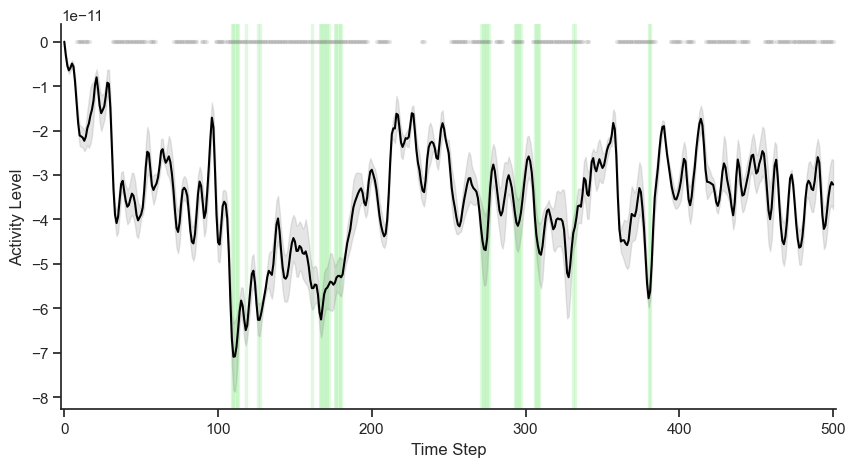

In [15]:
if p_value == 1.30103:
    COLOR = "lightgreen"
elif p_value == 2:
    COLOR = "lightblue"
elif p_value == 3:
    COLOR = "lightyellow"
COLOR = "lightgreen"
 
# 计算每列的平均值和标准差  
label_data_mean_values = np.mean(label_data, axis=0)  
label_data_std_values = np.std(label_data, axis=0)  

sns.set(style='ticks')  
sns.despine()
# 计算阴影区域的上下边界  
upper_bound = label_data_mean_values + label_data_std_values  
lower_bound = label_data_mean_values - label_data_std_values  
plt.figure(figsize=(10,5))

# 绘制显著时间点的标记（淡绿色矩形）  
for index in effective_time_point_without_fdr:  
    # 设置矩形的位置和大小  
    # 假设矩形的高度足够高以覆盖整个y轴范围，宽度为1（因为是时间点）  
    # plt.axvspan(index - 0.5, index + 0.5, alpha=0.3, color='lightgreen', ymin=0, ymax=np.max(label_data))  
    # plt.axvspan(index - 0.65, index + 0.65, alpha=0.1, color='gray', ymin=0, ymax=1)  
    plt.plot([index - 0.5, index + 0.5], [np.max(label_data),np.max(label_data)], linestyle='-', color='gray', linewidth=3,alpha=0.2)


for index in effective_time_point:  
    # 设置矩形的位置和大小  
    # 假设矩形的高度足够高以覆盖整个y轴范围，宽度为1（因为是时间点）  
    # plt.axvspan(index - 0.5, index + 0.5, alpha=0.3, color='lightgreen', ymin=0, ymax=np.max(label_data))  
    plt.axvspan(index - 0.65, index + 0.65, alpha=0.2, color=COLOR, ymin=0, ymax=1)  
    # plt.plot([index - 0.5, index + 0.5], [np.max(label_data),np.max(label_data)], linestyle='-', color=COLOR, linewidth=3,alpha=1.0)


# 绘制平均值的线  
plt.plot(range(label_data.shape[1]), label_data_mean_values, label='Mean', color='black')  
  
# 绘制阴影区域  
plt.fill_between(range(label_data.shape[1]), lower_bound, upper_bound, alpha=0.2, color='gray')  
plt.xlim(xmin=-2,xmax=502)
# 设置x轴和y轴的标签  
plt.xlabel('Time Step')  
plt.ylabel('Activity Level')  
  
# 添加图例  
# plt.legend()  
sns.set(style='ticks')  
sns.despine()
# 显示图像  
plt.show()

In [ ]:
# name     before_FDR                         after_FDR
# EFE1     frontalpole_1-rh                   frontalpole_1-rh
# AI1      middletemporal_5-lh                precentral_12-lh medialorbitofrontal_5-lh
# EFE2     rostralmiddlefrontal_1-lh          rostralmiddlefrontal_1-lh
# AL2      middletemporal_5-lh                rostralmiddlefrontal_6-lh
# RAI1     medialorbitofrontal_5-lh           medialorbitofrontal_5-lh
# RAL2     middletemporal_5-rh                NO RESULTS/precentral_15-rh

# EX1 middle temporal gyrus (6, right half)
# EX2 rostral middle frontal gyrus (6, left half)
# REX2 lateral occipital cortex (3, right half)
# PEEX2 lateral occipital cortex (3, right half)
# UAL frontal pole (1, left half)